#### **Paralelization**

In [24]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ.get('OPENAI_API_KEY'):
    print('key is set')
else:
    raise ValueError('Key is not set')

llm_model = ChatOpenAI(model = 'gpt-4-0613')
llm_model.invoke('what is the 2nd capital of Maharashtra')

key is set


AIMessage(content="Nagpur is considered the second capital of Maharashtra. It is used during winter sessions of the state's legislative assembly.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 16, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-DHQF0kKY7wC166PybdS2epIMAdCdF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd1b4-e000-7d32-bb0f-96571baff9de-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 24, 'total_tokens': 40, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

#### **Define Model/Schema**

In [25]:
from typing import TypedDict

class graph_schema(TypedDict):
    topic: str
    insta: str
    facebook: str
    linkdin: str

#### **Define Nodes**

In [26]:
def create_insta_post(state:graph_schema):
    topic = state['topic']
    response = llm_model.invoke(f'write a insta post on {topic}:')
    state['insta'] = response
    return {'insta': response}

def create_facebook_post(state:graph_schema):
    topic = state['topic']
    response = llm_model.invoke(f'write a facebook post on {topic}:')
    state['facebook'] = response
    return {'facebook': response}

def create_linkdin_post(state:graph_schema):
    topic = state['topic']
    response = llm_model.invoke(f'write a linkdin post on {topic}:')
    state['linkdin'] = response
    return {'linkdin': response}
    

#### **State Graph**

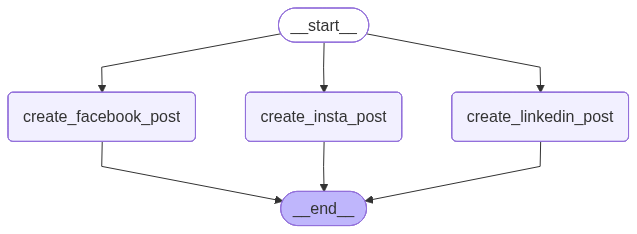

In [27]:

from langgraph.graph import StateGraph, END, START

graph = StateGraph(graph_schema)

## add nodes
graph.add_node('create_insta_post', create_insta_post)
graph.add_node('create_facebook_post', create_facebook_post)
graph.add_node('create_linkedin_post',create_linkdin_post)

## add edges
graph.add_edge(START, 'create_facebook_post')
graph.add_edge(START, 'create_insta_post')
graph.add_edge(START, 'create_linkedin_post')

graph.add_edge('create_facebook_post', END)
graph.add_edge('create_insta_post', END)
graph.add_edge('create_linkedin_post', END)

parallel_graph = graph.compile()

from IPython.display import Image
Image(parallel_graph.get_graph().draw_mermaid_png())

#### **Test**

In [28]:
parallel_graph.invoke(
    {
        'topic':'Artifical Intelligent',
        'facebook':'',
        'insta':'',
        'linkin':''
    }
)

{'topic': 'Artifical Intelligent',
 'insta': AIMessage(content="Exploring the incredible world of #ArtificialIntelligence.🚀 It's amazing to see how AI is shaping our future - from predictive analytics to enhancing business operations and even automating various tasks! AI is not just technology, it's a revolution transforming all industries. Can't wait to see what's next on the horizon. 💻🧠 #AI #TechTuesday #FutureIsHere #Innovation #MachineLearning #TechRevolution", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 18, 'total_tokens': 109, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-DHQF44qnpcIWZCdYQhvCV5uexHHAW', 'service_tier': 'default', 'finish_reason': 'stop', '